# Comparación temporal de ángulo — Shoulder Abducción/Adducción
Modifica **solo la celda de configuración**. El resto se ejecuta automáticamente.

In [1]:
# ── Dependencias ─────────────────────────────────────────────────────────────
# Si falta alguna: pip install ezc3d numpy scipy matplotlib
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.signal import find_peaks
import ezc3d

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CONFIGURACIÓN  ← editar aquí para cada caso concreto
# ══════════════════════════════════════════════════════════════════════════════

# -- Grabaciones por lado -----------------------------------------------------
SIDES_RECORDINGS = {
    "Left": [
        {"path": r"C:\Projects\c3d_data_organized\grab_5\Pie_Complete_Shoulder_Abd_Add_Left_Cont01.c3d",  "label": "Completo"},
        {"path": r"C:\Projects\c3d_data_organized\grab_5\Pie_C7_Shoulder_Abd_Add_Left_Cont01.c3d",        "label": "Con C7"},
        {"path": r"C:\Projects\c3d_data_organized\grab_5\Pie_NOT_C7_Shoulder_Abd_Add_Left_Cont01.c3d",    "label": "Sin C7"},
    ],
    "Right": [
        {"path": r"C:\Projects\c3d_data_organized\grab_5\Pie_Complete_Shoulder_Abd_Add_Right_Cont01.c3d", "label": "Completo"},
        {"path": r"C:\Projects\c3d_data_organized\grab_5\Pie_C7_Shoulder_Abd_Add_Right_Cont01.c3d",       "label": "Con C7"},
        {"path": r"C:\Projects\c3d_data_organized\grab_5\Pie_NOT_C7_Shoulder_Abd_Add_Right_Cont01.c3d",   "label": "Sin C7"},
    ],
}

# -- Variable SULM a analizar -------------------------------------------------
VARIABLE_NAME = "Humerothoracic_XZY_Op1"

# Componente Euler: 0 = X (Rot1), 1 = Y (Rot2), 2 = Z (Rot3)
COMPONENT_INDEX = 0  # Eje X

# -- Eje temporal -------------------------------------------------------------
NORMALIZE_TIME = False

# -- Media ± DE por repetición en lugar de señal cruda -----------------------
SHOW_MEAN_BAND = False

# Parámetros de segmentación (solo si SHOW_MEAN_BAND = True)
PROMINENCE          = 15.0
MIN_DISTANCE        = 60
HALFCYCLE_DIRECTION = "peak_to_valley"  # "peak_to_valley" o "valley_to_peak"

# -- Apariencia ---------------------------------------------------------------
COLORS     = ["#E74C3C", "#2E86C1", "#27AE60"]
ALPHA_RAW  = 0.85
ALPHA_BAND = 0.18
LINE_WIDTH = 1.5

TITLE   = "Humerothoracic — Abducción/Adducción"
Y_LABEL = "Ángulo (°)"

OUTPUT_PATH = None
DPI         = 150
# ══════════════════════════════════════════════════════════════════════════════

In [3]:
# ── Lectura de C3D (autónoma, sin importar data_processing.py) ───────────────

def read_c3d(filepath):
    """Lee un C3D de Vicon Nexus y devuelve frame_rate, n_frames, model_outputs."""
    filepath = os.path.normpath(os.path.abspath(filepath))
    c = ezc3d.c3d(filepath)

    raw_labels = c["parameters"]["POINT"]["LABELS"]["value"]
    point_data = c["data"]["points"]          # (4, n_labels, n_frames)
    n_labels   = min(len(raw_labels), point_data.shape[1])

    try:
        rate_val   = c["parameters"]["POINT"]["RATE"]["value"]
        frame_rate = int(float(rate_val[0]) if hasattr(rate_val, "__len__") else float(rate_val))
    except (KeyError, IndexError, TypeError, ValueError):
        frame_rate = int(c["header"]["frame_rate"])

    # Strip subject prefix before ':'
    clean_labels = [
        lbl.split(":")[-1].strip() if ":" in lbl else lbl.strip()
        for lbl in raw_labels[:n_labels]
    ]

    model_outputs = {
        lbl: point_data[:3, i, :].copy()
        for i, lbl in enumerate(clean_labels)
    }

    return {
        "frame_rate":    frame_rate,
        "n_frames":      point_data.shape[2],
        "model_outputs": model_outputs,
    }


def extract_angle(c3d_path, variable, component, side):
    """Extrae la curva angular 1D de un C3D. Devuelve (array, frame_rate)."""
    c3d   = read_c3d(c3d_path)
    label = variable if side == "—" else side + variable
    mo    = c3d["model_outputs"]

    if label not in mo:
        available = [k for k in mo if variable in k or side in k]
        raise KeyError(
            f"Label '{label}' no encontrado en {os.path.basename(c3d_path)}.\n"
            f"Coincidencias parciales: {available}\n"
            f"Labels disponibles: {list(mo.keys())}"
        )

    return mo[label][component, :].astype(float), c3d["frame_rate"]

In [4]:
# ── Segmentación (autónoma, sin importar segmentation.py) ────────────────────

def auto_segment(angle, prominence, min_distance, direction="peak_to_valley"):
    """Detecta semiciclos (peak→valley o valley→peak) y devuelve lista de (start, end)."""
    clean   = np.where(np.isnan(angle), np.nanmean(angle), angle)
    peaks,   _ = find_peaks( clean, prominence=prominence, distance=min_distance)
    valleys, _ = find_peaks(-clean, prominence=prominence, distance=min_distance)

    combined = sorted(
        [(int(f), "peak") for f in peaks] + [(int(f), "valley") for f in valleys],
        key=lambda x: x[0],
    )

    if direction == "peak_to_valley":
        want = ("peak", "valley")
    else:
        want = ("valley", "peak")

    segments = [
        (combined[i][0], combined[i + 1][0])
        for i in range(len(combined) - 1)
        if combined[i][1] == want[0] and combined[i + 1][1] == want[1]
    ]
    return segments


def mean_band(angle, prominence, min_distance, direction):
    """Segmenta las reps, interpola a 101 puntos y devuelve (t%, media, DE)."""
    segments = auto_segment(angle, prominence, min_distance, direction)
    if not segments:
        raise RuntimeError("No se detectaron repeticiones. Ajusta PROMINENCE o MIN_DISTANCE.")

    x_norm = np.linspace(0, 100, 101)
    reps   = []
    for s, e in segments:
        seg   = angle[s:e + 1]
        t_seg = np.linspace(0, 100, len(seg))
        reps.append(np.interp(x_norm, t_seg, seg))

    mat  = np.vstack(reps)
    mean = mat.mean(axis=0)
    std  = mat.std(axis=0, ddof=1) if mat.shape[0] > 1 else np.zeros(101)
    return x_norm, mean, std, len(segments)

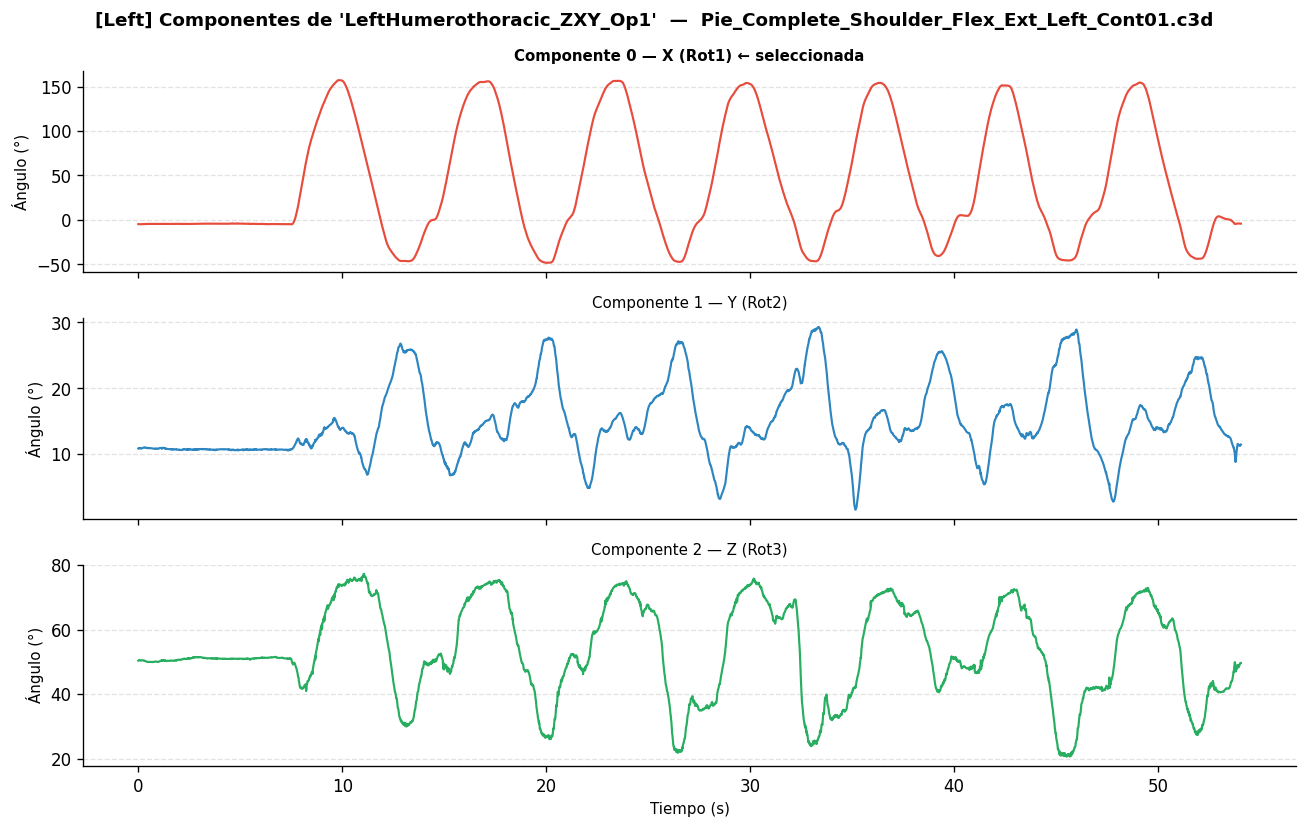

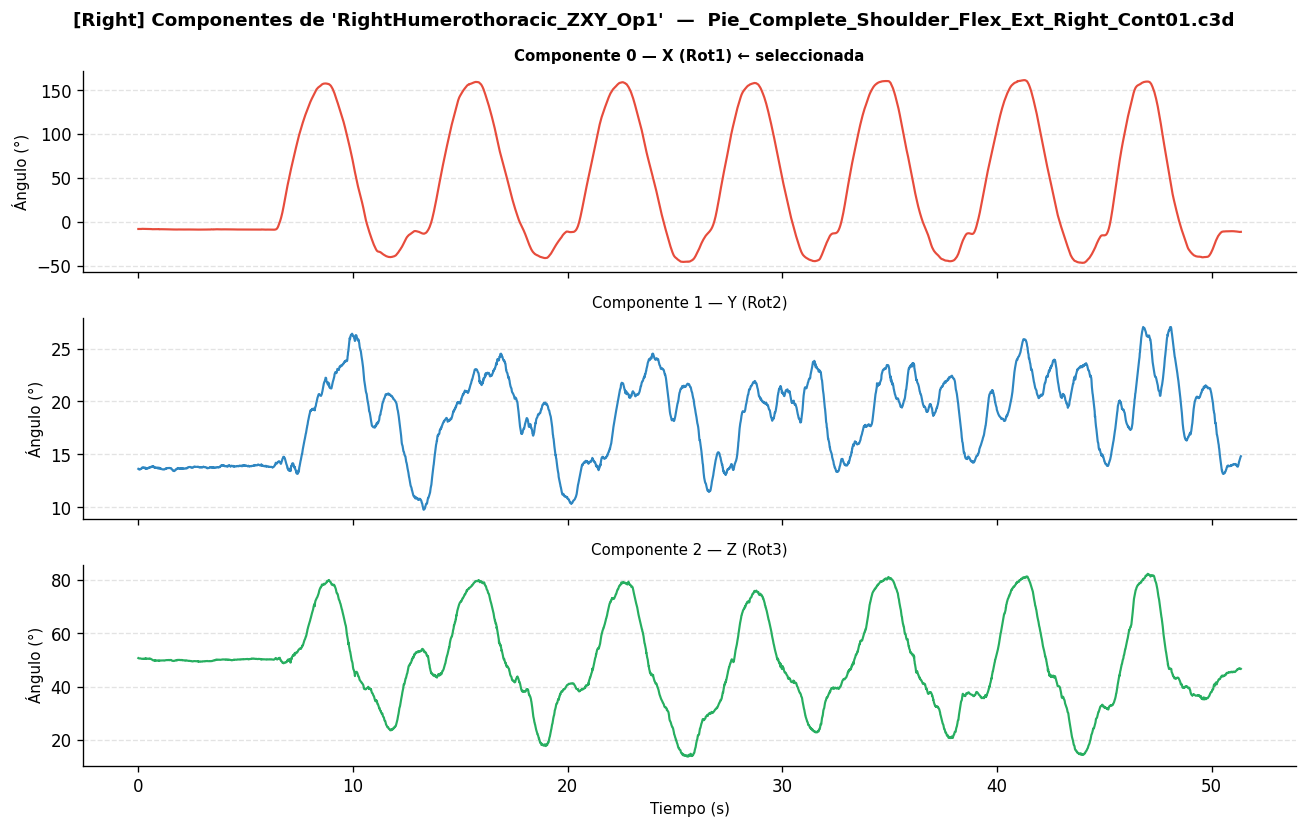

In [5]:
# ── Diagnóstico: ver las 3 componentes (X, Y, Z) de la primera grabación ─────
# Ejecuta esta celda para identificar qué componente corresponde al movimiento
# que te interesa antes de fijar COMPONENT_INDEX en la configuración.

_component_names  = ["X (Rot1)", "Y (Rot2)", "Z (Rot3)"]
_component_colors = ["#E74C3C", "#2E86C1", "#27AE60"]

for SIDE, C3D_RECORDINGS in SIDES_RECORDINGS.items():
    _rec   = C3D_RECORDINGS[0]
    _c3d   = read_c3d(_rec["path"])
    _label = VARIABLE_NAME if SIDE == "—" else SIDE + VARIABLE_NAME
    _data  = _c3d["model_outputs"][_label]
    _fr    = _c3d["frame_rate"]
    _t     = np.arange(_data.shape[1]) / _fr

    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
    fig.suptitle(f"[{SIDE}] Componentes de '{_label}'  —  {os.path.basename(_rec['path'])}",
                 fontsize=11, fontweight="bold")

    for idx, (name, color) in enumerate(zip(_component_names, _component_colors)):
        ax = axes[idx]
        ax.plot(_t, _data[idx], color=color, linewidth=1.3)
        ax.set_ylabel("Ángulo (°)", fontsize=9)
        ax.set_title(f"Componente {idx} — {name}"
                     + (" ← seleccionada" if idx == COMPONENT_INDEX else ""),
                     fontsize=9, fontweight="bold" if idx == COMPONENT_INDEX else "normal")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.yaxis.grid(True, linestyle="--", alpha=0.35)

    axes[-1].set_xlabel("Tiempo (s)", fontsize=9)
    plt.tight_layout()
    plt.show()

[Left] Leyendo: Pie_Complete_Shoulder_Flex_Ext_Left_Cont01.c3d
[Left] Leyendo: Pie_C7_Shoulder_Flex_Ext_Left_Cont01.c3d
[Left] Leyendo: Pie_NOT_C7_Shoulder_Flex_Ext_Left_Cont01.c3d


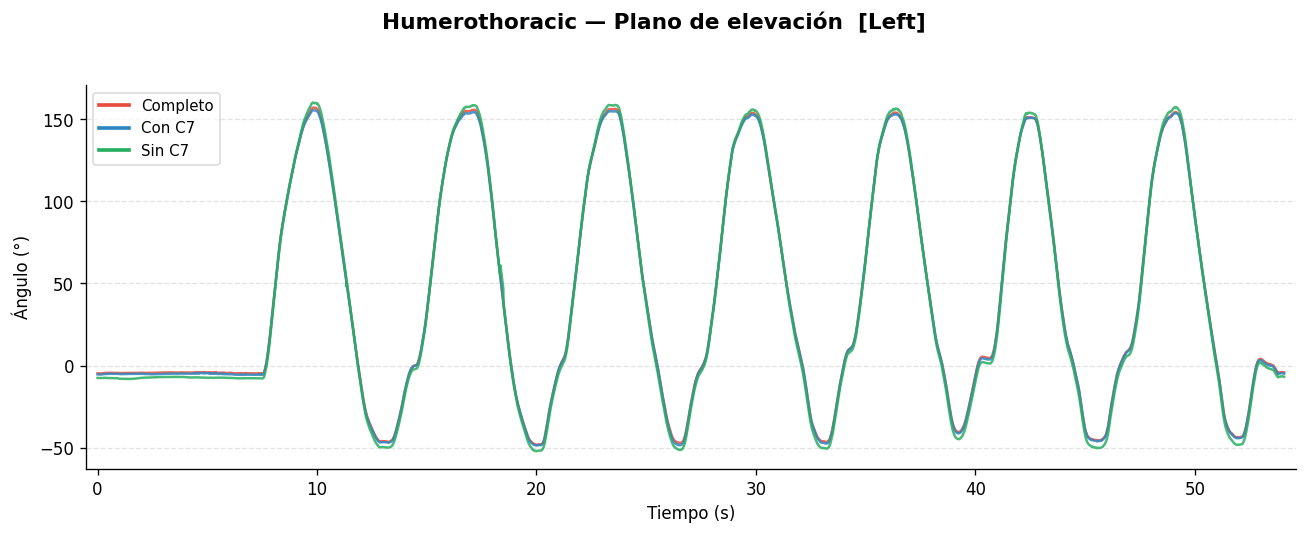

[Right] Leyendo: Pie_Complete_Shoulder_Flex_Ext_Right_Cont01.c3d
[Right] Leyendo: Pie_C7_Shoulder_Flex_Ext_Right_Cont01.c3d
[Right] Leyendo: Pie_NOT_C7_Shoulder_Flex_Ext_Right_Cont01.c3d


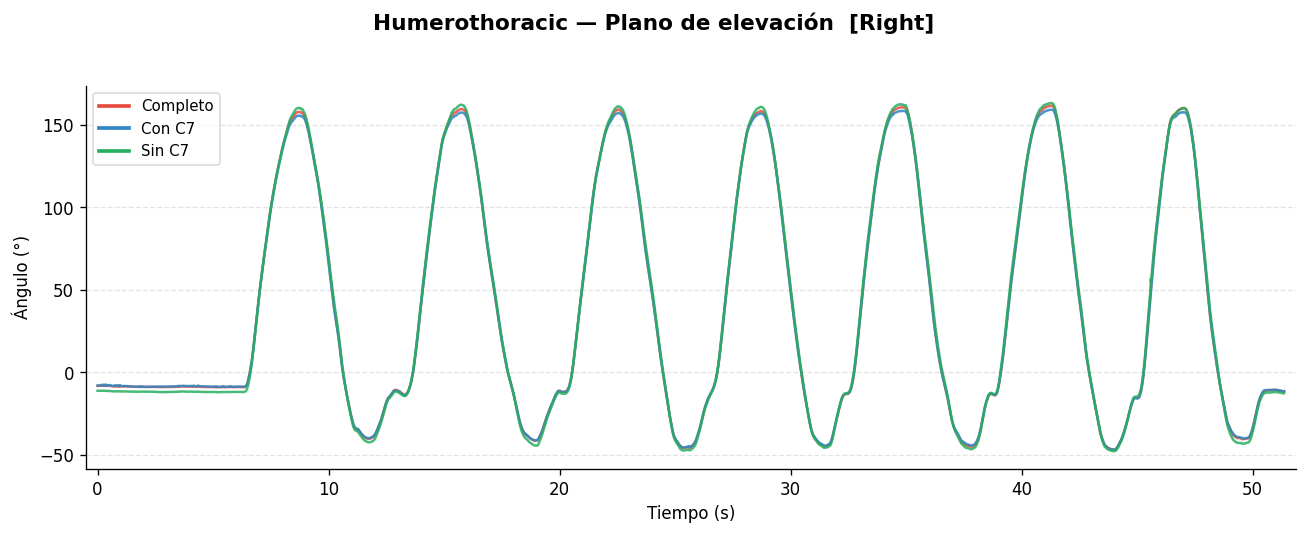

In [6]:
# ── Generar el gráfico de ángulos en el tiempo ────────────────────────────────

for SIDE, C3D_RECORDINGS in SIDES_RECORDINGS.items():
    fig, ax = plt.subplots(figsize=(11, 4.5))
    fig.subplots_adjust(top=0.88)
    fig.suptitle(f"{TITLE}  [{SIDE}]", fontsize=13, fontweight="bold")

    legend_handles = []

    for i, rec in enumerate(C3D_RECORDINGS):
        color = COLORS[i % len(COLORS)]
        print(f"[{SIDE}] Leyendo: {os.path.basename(rec['path'])}")

        angle, fr = extract_angle(rec["path"], VARIABLE_NAME, COMPONENT_INDEX, SIDE)

        if SHOW_MEAN_BAND:
            t, mean, std, n_reps = mean_band(angle, PROMINENCE, MIN_DISTANCE, HALFCYCLE_DIRECTION)
            ax.plot(t, mean, color=color, linewidth=LINE_WIDTH + 0.3, alpha=ALPHA_RAW)
            ax.fill_between(t, mean - std, mean + std, color=color, alpha=ALPHA_BAND)
            lbl = f"{rec['label']}  (n={n_reps} reps)"
        else:
            t = np.arange(len(angle)) / fr
            if NORMALIZE_TIME:
                t = t / t[-1] * 100.0
            ax.plot(t, angle, color=color, linewidth=LINE_WIDTH, alpha=ALPHA_RAW)
            lbl = rec["label"]

        legend_handles.append(
            mlines.Line2D([], [], color=color, linewidth=2.2, label=lbl)
        )

    if SHOW_MEAN_BAND:
        ax.set_xlabel("Ciclo normalizado (%)", fontsize=10)
    elif NORMALIZE_TIME:
        ax.set_xlabel("Tiempo normalizado (%)", fontsize=10)
    else:
        ax.set_xlabel("Tiempo (s)", fontsize=10)

    ax.set_ylabel(Y_LABEL, fontsize=10)
    ax.legend(handles=legend_handles, fontsize=9, framealpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.margins(x=0.01)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if OUTPUT_PATH:
        out = OUTPUT_PATH.replace(".", f"_{SIDE}.")
        fig.savefig(out, dpi=DPI, bbox_inches="tight")
        print(f"Guardado en: {out}")

    plt.show()

In [10]:
# ── Cálculo de diferencias por lado ──────────────────────────────────────────

data_by_side = {}

for SIDE, C3D_RECORDINGS in SIDES_RECORDINGS.items():
    raw_signals = {}
    frame_rates = {}
    for rec in C3D_RECORDINGS:
        angle, fr = extract_angle(rec["path"], VARIABLE_NAME, COMPONENT_INDEX, SIDE)
        raw_signals[rec["label"]] = angle
        frame_rates[rec["label"]] = fr

    min_frames = min(len(v) for v in raw_signals.values())
    signals    = {k: v[:min_frames] for k, v in raw_signals.items()}

    fr_ref = frame_rates["Completo"]
    t_s    = np.arange(min_frames) / fr_ref

    ref        = signals["Completo"]
    diff_c7    = signals["Con C7"] - ref
    diff_no_c7 = signals["Sin C7"] - ref

    data_by_side[SIDE] = {
        "signals":    signals,
        "t_s":        t_s,
        "diff_c7":    diff_c7,
        "diff_no_c7": diff_no_c7,
        "min_frames": min_frames,
        "fr_ref":     fr_ref,
    }

    print(f"[{SIDE}] Frames usados: {min_frames}  ({min_frames / fr_ref:.2f} s)")

[Left] Frames usados: 5408  (54.08 s)
[Right] Frames usados: 5137  (51.37 s)


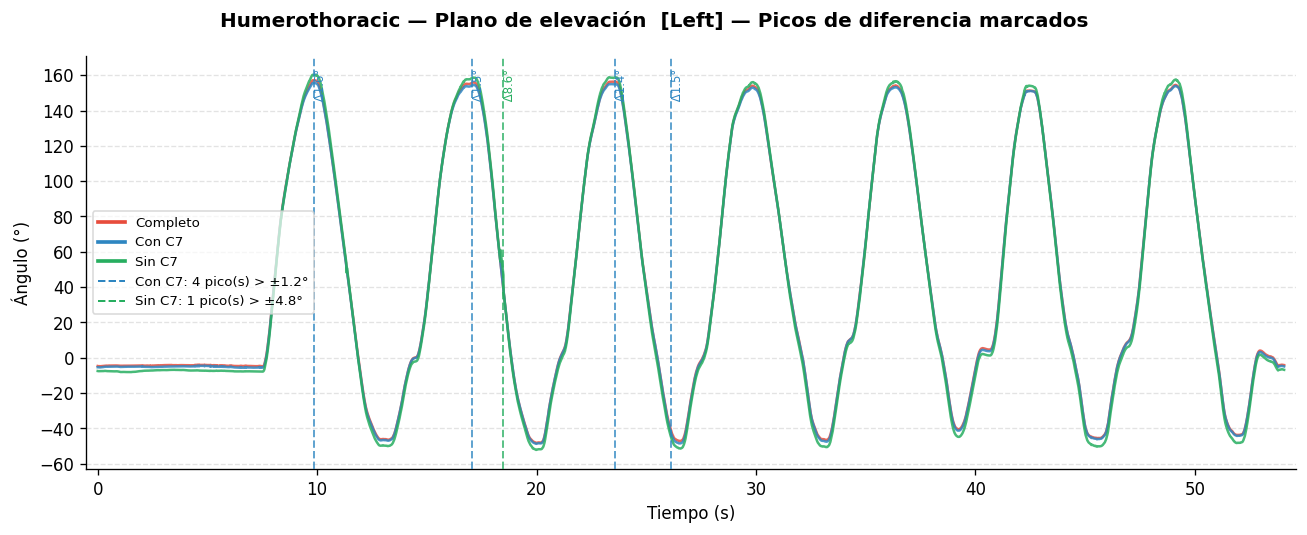


[Left] Umbral: MAE + 2.0σ

Con C7  (umbral = 1.23°):
  t = 9.86 s  →  Δ = 1.62°
  t = 17.05 s  →  Δ = 1.48°
  t = 23.58 s  →  Δ = 1.45°
  t = 26.14 s  →  Δ = 1.49°

Sin C7  (umbral = 4.83°):
  t = 18.47 s  →  Δ = 8.63°


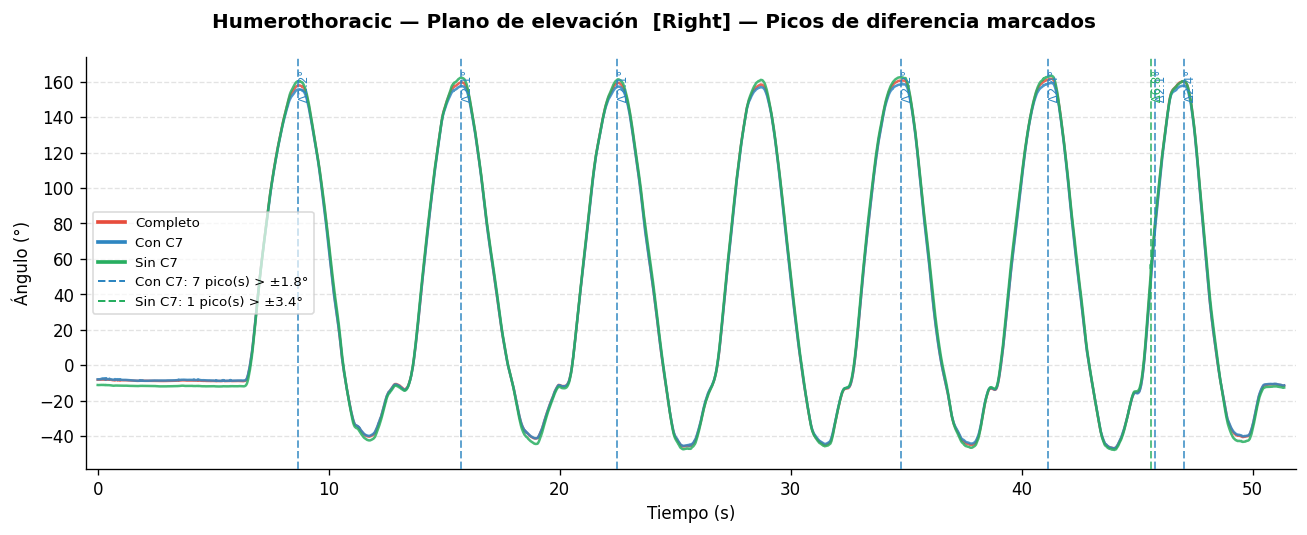


[Right] Umbral: MAE + 2.0σ

Con C7  (umbral = 1.83°):
  t = 8.66 s  →  Δ = 2.25°
  t = 15.71 s  →  Δ = 2.14°
  t = 22.49 s  →  Δ = 2.11°
  t = 34.77 s  →  Δ = 2.21°
  t = 41.15 s  →  Δ = 2.36°
  t = 45.76 s  →  Δ = 2.08°
  t = 47.02 s  →  Δ = 2.39°

Sin C7  (umbral = 3.40°):
  t = 45.59 s  →  Δ = 6.79°


In [11]:
# ── Localizar picos prominentes de diferencia sobre la señal original ─────────
# Un pico se considera prominente si supera SPIKE_THRESHOLD desviaciones típicas
# por encima de la diferencia media absoluta.
# ─────────────────────────────────────────────────────────────────────────────

SPIKE_THRESHOLD = 2.0   # ← ajusta: cuántas σ sobre el MAE para marcar un pico

def _find_spike_times(diff, t, threshold_sd):
    """Devuelve los tiempos (s) donde |diff| supera mean(|diff|) + threshold_sd * std(|diff|)."""
    abs_diff = np.abs(diff)
    cutoff   = abs_diff.mean() + threshold_sd * abs_diff.std()
    above    = abs_diff > cutoff
    starts   = np.where(np.diff(above.astype(int)) == 1)[0]
    peaks    = [s + np.argmax(abs_diff[s: s + 50]) for s in starts]
    return t[peaks], abs_diff[peaks], cutoff

for SIDE, d in data_by_side.items():
    signals        = d["signals"]
    t_s            = d["t_s"]
    diff_c7        = d["diff_c7"]
    diff_no_c7     = d["diff_no_c7"]
    min_frames     = d["min_frames"]
    C3D_RECORDINGS = SIDES_RECORDINGS[SIDE]

    spikes_c7    = _find_spike_times(diff_c7,    t_s, SPIKE_THRESHOLD)
    spikes_no_c7 = _find_spike_times(diff_no_c7, t_s, SPIKE_THRESHOLD)

    spike_info = [
        ("Con C7", "#2E86C1", spikes_c7),
        ("Sin C7", "#27AE60", spikes_no_c7),
    ]

    fig, ax = plt.subplots(figsize=(11, 4.5))
    fig.suptitle(f"{TITLE}  [{SIDE}] — Picos de diferencia marcados", fontsize=12, fontweight="bold")

    legend_handles = []
    for i, rec in enumerate(C3D_RECORDINGS):
        color = COLORS[i % len(COLORS)]
        angle = signals[rec["label"]]
        ax.plot(t_s, angle[:min_frames], color=color, linewidth=LINE_WIDTH, alpha=ALPHA_RAW)
        legend_handles.append(mlines.Line2D([], [], color=color, linewidth=2.2, label=rec["label"]))

    for label, color, (times, magnitudes, cutoff) in spike_info:
        for tk, mag in zip(times, magnitudes):
            ax.axvline(tk, color=color, linewidth=1.2, linestyle="--", alpha=0.75, zorder=4)
            ylim = ax.get_ylim()
            ax.text(tk, ylim[0] + (ylim[1] - ylim[0]) * 0.97,
                    f" Δ{mag:.1f}°", color=color, fontsize=7,
                    va="top", rotation=90, zorder=5)
        if len(times):
            legend_handles.append(
                mlines.Line2D([], [], color=color, linewidth=1.2, linestyle="--",
                              label=f"{label}: {len(times)} pico(s) > ±{cutoff:.1f}°")
            )

    ax.set_xlabel("Tiempo (s)", fontsize=10)
    ax.set_ylabel(Y_LABEL, fontsize=10)
    ax.legend(handles=legend_handles, fontsize=8, framealpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.locator_params(axis="y", nbins=12)
    ax.margins(x=0.01)
    plt.tight_layout()
    plt.show()

    print(f"\n[{SIDE}] Umbral: MAE + {SPIKE_THRESHOLD}σ")
    for label, _, (times, magnitudes, cutoff) in spike_info:
        print(f"\n{label}  (umbral = {cutoff:.2f}°):")
        if len(times) == 0:
            print("  Sin picos prominentes")
        for tk, mag in zip(times, magnitudes):
            print(f"  t = {tk:.2f} s  →  Δ = {mag:.2f}°")


[Left]
                              Con C7      Sin C7
MAE (°)                         0.52        2.38
RMSE (°)                        0.63        2.67
Máx |diferencia| (°)            1.62        8.63
Sesgo medio (°)                -0.51       -1.39


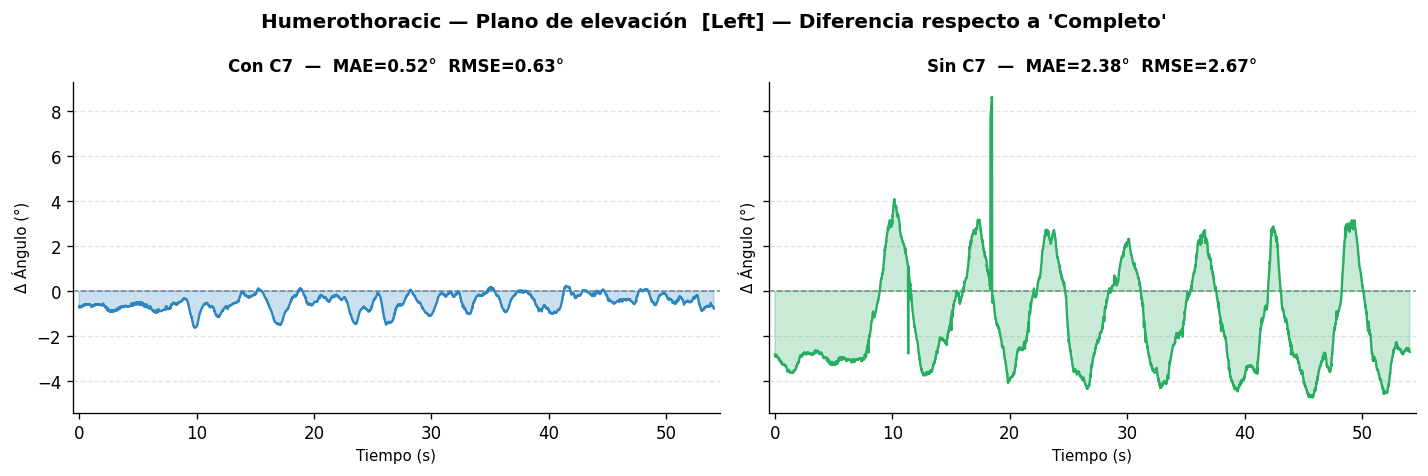


[Right]
                              Con C7      Sin C7
MAE (°)                         0.66        1.51
RMSE (°)                        0.88        1.78
Máx |diferencia| (°)            2.39        6.79
Sesgo medio (°)                -0.40       -0.01


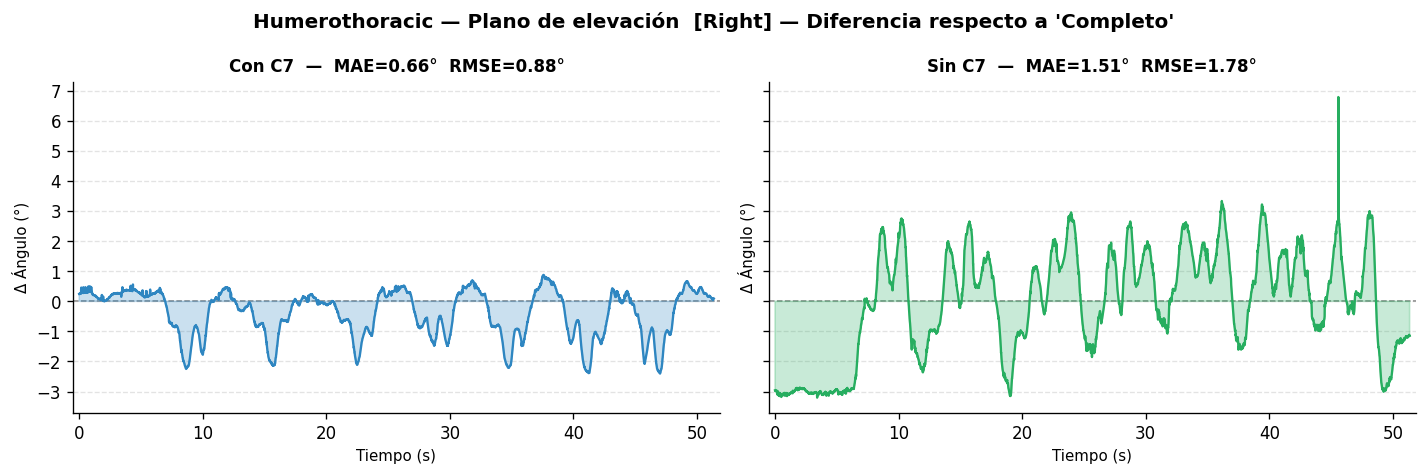

In [12]:
# ── Gráfico de distancias angulares respecto al modelo Completo ───────────────

def _stats(d):
    return {
        "MAE":  np.mean(np.abs(d)),
        "RMSE": np.sqrt(np.mean(d**2)),
        "MAX":  np.max(np.abs(d)),
        "BIAS": np.mean(d),
    }

for SIDE, d in data_by_side.items():
    t_s        = d["t_s"]
    diff_c7    = d["diff_c7"]
    diff_no_c7 = d["diff_no_c7"]

    s_c7    = _stats(diff_c7)
    s_no_c7 = _stats(diff_no_c7)

    print(f"\n[{SIDE}]")
    print(f"{'':24s}  {'Con C7':>10s}  {'Sin C7':>10s}")
    print(f"{'MAE (°)':24s}  {s_c7['MAE']:>10.2f}  {s_no_c7['MAE']:>10.2f}")
    print(f"{'RMSE (°)':24s}  {s_c7['RMSE']:>10.2f}  {s_no_c7['RMSE']:>10.2f}")
    print(f"{'Máx |diferencia| (°)':24s}  {s_c7['MAX']:>10.2f}  {s_no_c7['MAX']:>10.2f}")
    print(f"{'Sesgo medio (°)':24s}  {s_c7['BIAS']:>10.2f}  {s_no_c7['BIAS']:>10.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    fig.suptitle(f"{TITLE}  [{SIDE}] — Diferencia respecto a 'Completo'", fontsize=12, fontweight="bold")

    for ax, diff, label, color, s in [
        (axes[0], diff_c7,    "Con C7", "#2E86C1", s_c7),
        (axes[1], diff_no_c7, "Sin C7", "#27AE60", s_no_c7),
    ]:
        ax.axhline(0, color="gray", linewidth=0.9, linestyle="--", zorder=1)
        ax.fill_between(t_s, diff, 0, where=(diff >= 0), color=color, alpha=0.25, zorder=2)
        ax.fill_between(t_s, diff, 0, where=(diff <  0), color=color, alpha=0.25, zorder=2)
        ax.plot(t_s, diff, color=color, linewidth=1.4, zorder=3)
        ax.set_title(f"{label}  —  MAE={s['MAE']:.2f}°  RMSE={s['RMSE']:.2f}°",
                     fontsize=10, fontweight="bold")
        ax.set_xlabel("Tiempo (s)", fontsize=9)
        ax.set_ylabel("Δ Ángulo (°)", fontsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
        ax.locator_params(axis="y", nbins=12)
        ax.margins(x=0.01)

    plt.tight_layout()
    plt.show()